# Fraud Detection in Electricity and Gas Consumption Challenge

This is a simple starter notebook based on the tutorial prepared by Joy Wawira. Check out the article [here](https://zindi.africa/learn/fraud-detection-in-electricity-and-gas-consumption-challenge-tutorial) for a more detailed description of the steps taken.

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out simple EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Data Prep

## Import Libraries

In [539]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm
from lightgbm import LGBMClassifier

import warnings
warnings.simplefilter('ignore')

## Read the Data

In [540]:
client_train = pd.read_csv('data/train/client_train.csv', low_memory=False)
invoice_train = pd.read_csv('data/train/invoice_train.csv', low_memory=False)

client_test = pd.read_csv('data/test/client_test.csv', low_memory=False)
invoice_test = pd.read_csv('data/test/invoice_test.csv', low_memory=False)
sample_submission = pd.read_csv('data/SampleSubmission.csv', low_memory=False)

## Data Understanding

In [541]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_train.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [542]:
#print top rows of dataset
invoice_train.head(20)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
5,train_Client_0,2017-07-17,11,1335667,0,207,9,1,314,0,0,0,15638,15952,8,ELEC
6,train_Client_0,2018-12-07,11,1335667,0,207,9,1,541,0,0,0,15952,16493,12,ELEC
7,train_Client_0,2019-03-19,11,1335667,0,207,9,1,585,0,0,0,16493,17078,8,ELEC
8,train_Client_0,2011-07-22,11,1335667,0,203,9,1,1200,186,0,0,7770,9156,4,ELEC
9,train_Client_0,2011-11-22,11,1335667,0,203,6,1,1082,0,0,0,9156,10238,4,ELEC


In [543]:
#print top rows of dataset
client_train.head(20)

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0
5,69,train_Client_10000,11,103,29/09/1993,0.0
6,62,train_Client_100000,11,309,07/06/2012,0.0
7,60,train_Client_100001,11,101,12/04/2006,0.0
8,62,train_Client_100002,11,301,31/12/2006,0.0
9,60,train_Client_100003,11,101,25/10/2011,0.0


In [544]:
#Get a summary for all numerical columns
invoice_train.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [545]:
#Get a summary for all numerical columns
client_train.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [546]:
#Get concise information of each column in dataset
invoice_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype
---  ------                -----
 0   client_id             str  
 1   invoice_date          str  
 2   tarif_type            int64
 3   counter_number        int64
 4   counter_statue        str  
 5   counter_code          int64
 6   reading_remarque      int64
 7   counter_coefficient   int64
 8   consommation_level_1  int64
 9   consommation_level_2  int64
 10  consommation_level_3  int64
 11  consommation_level_4  int64
 12  old_index             int64
 13  new_index             int64
 14  months_number         int64
 15  counter_type          str  
dtypes: int64(12), str(4)
memory usage: 546.5 MB


In [547]:
#Get concise information of each column in dataset
client_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  str    
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  str    
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 6.2 MB


In [548]:
#Getting unique values on the invoice train data
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [549]:
#Getting unique values on the invoice train data
for col in client_train.columns:
    print(f"{col} - {client_train[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2


In [550]:
#check for missing values
invoice_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [551]:
#check for missing values
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

No missing values in train set

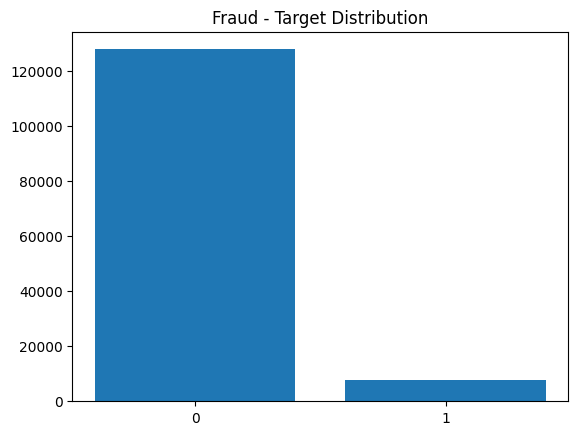

In [552]:
#Visualize fraudulent activities
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

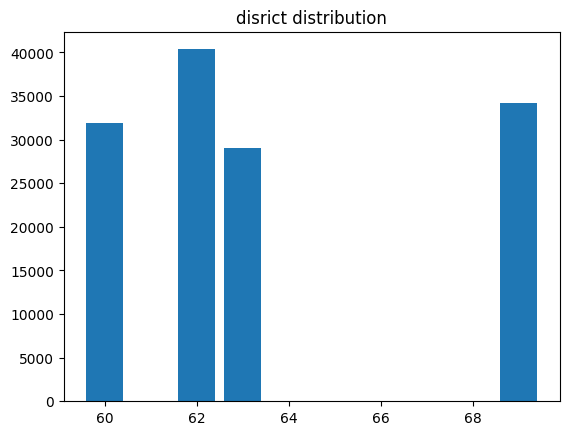

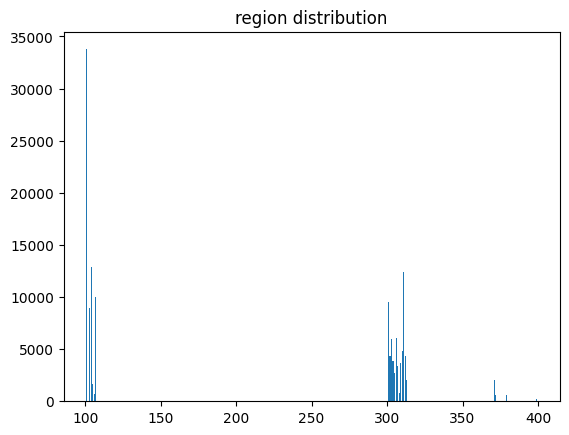

In [553]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [554]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [555]:
for df in [invoice_train, invoice_test]:

    df['invoice_month'] = df['invoice_date'].dt.month
    df['invoice_year'] = df['invoice_date'].dt.year

In [556]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [557]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

In [558]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean','std','max']
    aggs['consommation_level_2'] = ['mean','std','max']
    aggs['consommation_level_3'] = ['mean','std','max']
    aggs['consommation_level_4'] = ['mean','std','max']
    aggs['invoice_month'] = ['mean','std']
    aggs['invoice_year'] = ['mean']
    aggs['months_number'] = ['mean','max']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (
    invoice_data.groupby('client_id')
    .size()
    .reset_index(name='transactions_count')
)
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [559]:
#group invoice data by client_id
agg_train = aggregate_by_client_id(invoice_train)

In [560]:
print(agg_train.shape)
agg_train.head()

(135493, 19)


,client_id,transactions_count,consommation_level_1_mean,consommation_level_1_std,consommation_level_1_max,consommation_level_2_mean,consommation_level_2_std,consommation_level_2_max,consommation_level_3_mean,consommation_level_3_std,consommation_level_3_max,consommation_level_4_mean,consommation_level_4_std,consommation_level_4_max,invoice_month_mean,invoice_month_std,invoice_year_mean,months_number_mean,months_number_max
0,train_Client_0,35,352.400000,310.343472,1200,10.571429,43.568935,186,0.000000,0.000000,0,0.000000,0.000000,0,6.685714,3.587326,2011.142857,4.628571,12
1,train_Client_1,37,557.540541,197.935960,1207,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000,0,5.135135,3.128384,2011.837838,4.324324,8
2,train_Client_10,18,798.611111,513.841374,2400,37.888889,160.748942,682,0.000000,0.000000,0,0.000000,0.000000,0,6.611111,3.292396,2010.944444,6.444444,12
3,train_Client_100,20,1.200000,3.607011,15,0.000000,0.000000,0,0.000000,0.000000,0,0.000000,0.000000,0,5.550000,3.203206,2008.600000,4.200000,6
4,train_Client_1000,14,663.714286,224.831365,800,104.857143,167.155320,400,117.357143,289.433294,800,36.714286,105.421081,382,7.571429,3.390355,2016.857143,3.714286,4


In [561]:
#merge aggregate data with client dataset
train = pd.merge(client_train,agg_train, on='client_id', how='left')

In [562]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [563]:
train.shape, test.shape

((135493, 24), (58069, 23))

In [564]:
#drop redundant columns
sub_client_id = test['client_id']
drop_columns = ['client_id', 'creation_date']

for col in drop_columns:
    if col in train.columns:
        train.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

# Modelling

## Train LGBM *Classifier*

In [565]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# features and target
X = train.drop(columns=['target'])
y = train['target']

# split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.fillna(X_train.median())
X_val = X_val.fillna(X_train.median())

# train model
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

# probabilities instead of direct prediction
y_prob = model.predict_proba(X_val)[:,1]

best_f1 = 0
best_threshold = 0

for t in np.arange(0.01, 0.99, 0.01):

    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_val, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

[LightGBM] [Info] Number of positive: 6053, number of negative: 102341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4381
[LightGBM] [Info] Number of data points in the train set: 108394, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.055843 -> initscore=-2.827756
[LightGBM] [Info] Start training from score -2.827756
Best threshold: 0.65
Best F1 score: 0.23691137759578823


In [566]:
y_pred = (y_prob > best_threshold).astype(int)

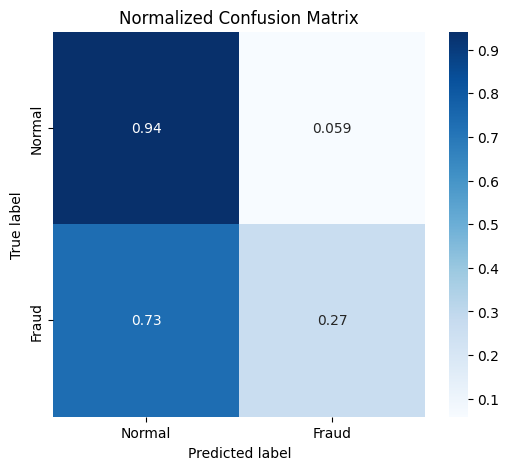

In [567]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm,
            annot=True,
            cmap="Blues",
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

The improved LightGBM configuration slightly increased the F1 score from approximately 0.236 to 0.237.
The model became more conservative, improving the detection of normal transactions (94%) while slightly reducing fraud recall.

## Make Predictions on test set

In [568]:
test.columns

Index(['disrict', 'client_catg', 'region', 'transactions_count',
       'consommation_level_1_mean', 'consommation_level_1_std',
       'consommation_level_1_max', 'consommation_level_2_mean',
       'consommation_level_2_std', 'consommation_level_2_max',
       'consommation_level_3_mean', 'consommation_level_3_std',
       'consommation_level_3_max', 'consommation_level_4_mean',
       'consommation_level_4_std', 'consommation_level_4_max',
       'invoice_month_mean', 'invoice_month_std', 'invoice_year_mean',
       'months_number_mean', 'months_number_max'],
      dtype='str')

In [569]:
test_prob = model.predict_proba(test)[:,1]
preds = (test_prob > best_threshold).astype(int)

preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0
1,0
2,0
3,0
4,0


In [570]:
submission = pd.DataFrame(
    {
        'client_id': sub_client_id,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0
1,test_Client_1,0
2,test_Client_10,0
3,test_Client_100,0
4,test_Client_1000,0


In [571]:
submission.to_csv('data/submission.csv', index=False)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation


# ******************* GOOD LUCK!!! ***************************